In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/elifzelik/phishing-url-features-dataset/dataset_info.txt
/kaggle/input/datasets/elifzelik/phishing-url-features-dataset/README.md
/kaggle/input/datasets/elifzelik/phishing-url-features-dataset/feature_description.csv
/kaggle/input/datasets/elifzelik/phishing-url-features-dataset/final_dataset.csv


In [3]:
import pandas as pd
import numpy as np
import os

csv_path = "/kaggle/input/datasets/elifzelik/phishing-url-features-dataset/final_dataset.csv"  # burayı kendi çıktına göre değiştir

df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

print("\nMissing values:")
print(df.isnull().sum())

print("\nLast column value counts:")
print(df.iloc[:, -1].value_counts())

Dataset shape: (579920, 76)

Columns:
['url', 'label', 'url_length', 'domain_length', 'hostname_length', 'path_length', 'first_dir_length', 'tld_length', 'tld_length_domain', 'url_depth', 'query_length', 'path_segments_count', 'num_digits', 'num_letters', 'num_special_chars', 'num_dots', 'num_hyphens', 'num_at', 'num_percent', 'num_equals', 'num_question', 'num_ampersand', 'num_hash', 'num_underscore', 'num_special', 'num_slash', 'num_params', 'entropy_url', 'entropy_hostname', 'entropy_domain', 'entropy_path', 'query_entropy', 'ratio_digits', 'ratio_letters', 'ratio_special_chars', 'uppercase_ratio', 'lowercase_ratio', 'is_ip_address', 'starts_with_ip', 'is_suspicious_tld', 'uses_https', 'has_www', 'unusual_double_slash', 'multiple_http', 'contains_port_number', 'path_has_encoded_chars', 'query_has_base64', 'contains_login', 'contains_secure', 'contains_verify', 'contains_account', 'contains_update', 'contains_bank', 'contains_cloud', 'contains_brand', 'query_key_count', 'query_value_

,url,label,url_length,domain_length,hostname_length,path_length,first_dir_length,tld_length,tld_length_domain,url_depth,...,whois_success,domain_age_days,expiration_days,creation_year,domain_is_recent,domain_registered_before_2020,registrar_valid,name_servers_count,is_privacy_protected,whois_missing
0,http://%20%25**)(**@fbrasil.com/old/lqjj0ukuvg...,1,57,7,24,26,3,3,3,3,...,1.0,5484.0,359.0,2010.0,0.0,1.0,1.0,2.0,0.0,0
1,https://*f003.backblazeb2.com*/file/pesosi/hom...,1,52,4,22,22,4,0,0,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,http://0-docusign-secured-843439-1-srs09.repli...,1,52,6,44,1,0,3,3,0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0
3,http://0-olx.1850943.xyz/,1,25,7,17,1,0,3,3,0,...,1.0,272.0,93.0,2025.0,1.0,0.0,1.0,2.0,0.0,0
4,http://0.0.0.0forum.cryptonight.net,1,35,11,28,0,0,3,3,0,...,1.0,475.0,254.0,2024.0,0.0,0.0,1.0,2.0,0.0,0



Missing values:
url                              0
label                            0
url_length                       0
domain_length                    0
hostname_length                  0
                                ..
domain_registered_before_2020    0
registrar_valid                  0
name_servers_count               0
is_privacy_protected             0
whois_missing                    0
Length: 76, dtype: int64

Last column value counts:
whois_missing
0    573075
1      6845
Name: count, dtype: int64


In [4]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D,
    Dense, Dropout, LSTM, Bidirectional, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

2026-06-09 21:22:31.211689: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781040151.378938      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781040151.426083      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781040151.843458      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781040151.843486      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781040151.843488      22 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [5]:
csv_path = "/kaggle/input/datasets/elifzelik/phishing-url-features-dataset/final_dataset.csv"

df = pd.read_csv(csv_path)

df = df[["url", "label"]].dropna()
df["url"] = df["url"].astype(str)
df["label"] = df["label"].astype(int)

print("Dataset shape:", df.shape)
print(df.head())

print("Label distribution:")
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True))

Dataset shape: (579920, 2)
                                                 url  label
0  http://%20%25**)(**@fbrasil.com/old/lqjj0ukuvg...      1
1  https://*f003.backblazeb2.com*/file/pesosi/hom...      1
2  http://0-docusign-secured-843439-1-srs09.repli...      1
3                          http://0-olx.1850943.xyz/      1
4                http://0.0.0.0forum.cryptonight.net      1
Label distribution:
label
0    339074
1    240846
Name: count, dtype: int64
label
0    0.584691
1    0.415309
Name: proportion, dtype: float64


In [6]:
urls = df["url"].values
labels = df["label"].values

X_train_url, X_temp_url, y_train, y_temp = train_test_split(
    urls,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

X_val_url, X_test_url, y_val, y_test = train_test_split(
    X_temp_url,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train_url))
print("Validation:", len(X_val_url))
print("Test:", len(X_test_url))

Train: 405944
Validation: 86988
Test: 86988


count    579920.000000
mean         51.629570
std          70.993632
min          12.000000
25%          32.000000
50%          41.000000
75%          55.000000
max       25523.000000
Name: url, dtype: float64
90%: 82.0
95%: 110.0
99%: 212.0


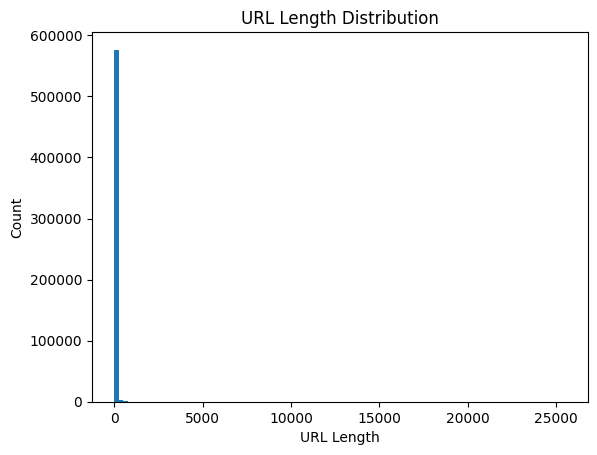

In [7]:
url_lengths = df["url"].apply(len)

print(url_lengths.describe())
print("90%:", np.percentile(url_lengths, 90))
print("95%:", np.percentile(url_lengths, 95))
print("99%:", np.percentile(url_lengths, 99))

plt.figure()
plt.hist(url_lengths, bins=100)
plt.title("URL Length Distribution")
plt.xlabel("URL Length")
plt.ylabel("Count")
plt.show()

In [8]:
MAX_LEN = 250
MAX_CHARS = 120

tokenizer = Tokenizer(
    num_words=MAX_CHARS,
    char_level=True,
    lower=False,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train_url)

X_train_seq = tokenizer.texts_to_sequences(X_train_url)
X_val_seq = tokenizer.texts_to_sequences(X_val_url)
X_test_seq = tokenizer.texts_to_sequences(X_test_url)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("Train padded:", X_train_pad.shape)
print("Validation padded:", X_val_pad.shape)
print("Test padded:", X_test_pad.shape)

vocab_size = min(MAX_CHARS, len(tokenizer.word_index) + 1)
print("Vocab size:", vocab_size)
print("Tokenizer characters:", tokenizer.word_index)

Train padded: (405944, 250)
Validation padded: (86988, 250)
Test padded: (86988, 250)
Vocab size: 120
Tokenizer characters: {'<OOV>': 1, 't': 2, '/': 3, 'e': 4, 's': 5, 'o': 6, 'a': 7, 'p': 8, '.': 9, 'i': 10, 'c': 11, 'r': 12, 'n': 13, 'h': 14, 'w': 15, 'm': 16, 'l': 17, 'd': 18, '-': 19, 'u': 20, ':': 21, 'g': 22, 'b': 23, 'f': 24, 'k': 25, 'y': 26, 'v': 27, '2': 28, '0': 29, '1': 30, '3': 31, '4': 32, '5': 33, '8': 34, '9': 35, '6': 36, '7': 37, 'x': 38, 'z': 39, 'j': 40, '%': 41, '=': 42, 'q': 43, '_': 44, 'A': 45, '&': 46, 'F': 47, 'D': 48, '?': 49, 'C': 50, 'N': 51, 'S': 52, 'M': 53, 'B': 54, 'T': 55, 'L': 56, 'E': 57, 'R': 58, 'I': 59, 'W': 60, 'Z': 61, 'X': 62, 'P': 63, 'U': 64, 'V': 65, 'Y': 66, 'G': 67, 'Q': 68, 'H': 69, 'J': 70, 'O': 71, 'K': 72, ';': 73, '#': 74, '@': 75, '+': 76, "'": 77, '\\': 78, '(': 79, ')': 80, ',': 81, '$': 82, 'ا': 83, '*': 84, ' ': 85, '~': 86, 'ر': 87, 'م': 88, '[': 89, ']': 90, 'ی': 91, '!': 92, 'ل': 93, 'و': 94, 'ن': 95, 'ت': 96, 'س': 97, 'ب': 9

In [9]:
classes = np.unique(y_train)

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_values)
}

print("Class weight:", class_weight)

Class weight: {0: 0.8551518419899559, 1: 1.203924266869128}


In [10]:
EPOCHS = 40
BATCH_SIZE = 1024
LEARNING_RATE = 1e-3
EMBEDDING_DIM = 64

def build_callbacks(model_name):
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=6,
            restore_best_weights=True
        ),
        ModelCheckpoint(
            f"/kaggle/working/{model_name}.keras",
            monitor="val_loss",
            save_best_only=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-6
        )
    ]


def evaluate_model(model, X_test_data, y_test_data, model_name, threshold=0.5):
    y_prob = model.predict(X_test_data, batch_size=2048).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    results = {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test_data, y_pred),
        "Precision": precision_score(y_test_data, y_pred, zero_division=0),
        "Recall": recall_score(y_test_data, y_pred, zero_division=0),
        "F1-score": f1_score(y_test_data, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_data, y_prob),
        "PR-AUC": average_precision_score(y_test_data, y_prob)
    }

    print("\n==============================")
    print(model_name)
    print("==============================")
    print(classification_report(y_test_data, y_pred, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test_data, y_pred))
    print(results)

    return results, y_prob


def find_best_threshold(y_true, y_prob):
    thresholds = np.arange(0.05, 0.96, 0.01)

    best_threshold = 0.5
    best_f1 = 0

    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)
        current_f1 = f1_score(y_true, y_pred, zero_division=0)

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = threshold

    return best_threshold, best_f1


def plot_history(history, model_name):
    plt.figure()
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

I0000 00:00:1781040179.455930      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781040179.461872      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 64)        │         7,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 246, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 246, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 123, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 123, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 121, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 121, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,905 (484.00 KB)

 Trainable params: 123,393 (482.00 KB)

...

  2/397 ━━━━━━━━━━━━━━━━━━━━ 30s 77ms/step - accuracy: 0.5220 - auc: 0.5366 - loss: 1.4396 - pr_auc: 0.4404   

I0000 00:00:1781040190.800577      68 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


396/397 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8655 - auc: 0.9315 - loss: 0.3237 - pr_auc: 0.9062

2026-06-09 21:23:32.532326: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng12{k11=2} for conv %cudnn-conv-bias-activation.7 = (f32[440,128,1,121]{3,2,1,0}, u8[0]{0}) custom-call(f32[440,128,1,123]{3,2,1,0} %bitcast.9738, f32[128,128,1,3]{3,2,1,0} %bitcast.9742, f32[128]{0} %bitcast.12646), window={size=1x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1/conv1d_1_2/convolution" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-06-09 21:23:33.485184: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.952958239s
Trying algorithm eng12{k1

397/397 ━━━━━━━━━━━━━━━━━━━━ 42s 81ms/step - accuracy: 0.9169 - auc: 0.9732 - loss: 0.2091 - pr_auc: 0.9648 - val_accuracy: 0.9414 - val_auc: 0.9907 - val_loss: 0.3213 - val_pr_auc: 0.9882 - learning_rate: 0.0010
Epoch 2/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.9538 - auc: 0.9899 - loss: 0.1240 - pr_auc: 0.9869 - val_accuracy: 0.9609 - val_auc: 0.9940 - val_loss: 0.1038 - val_pr_auc: 0.9922 - learning_rate: 0.0010
Epoch 3/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - accuracy: 0.9616 - auc: 0.9927 - loss: 0.1038 - pr_auc: 0.9905 - val_accuracy: 0.9694 - val_auc: 0.9953 - val_loss: 0.0820 - val_pr_auc: 0.9939 - learning_rate: 0.0010
Epoch 4/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - accuracy: 0.9657 - auc: 0.9940 - loss: 0.0936 - pr_auc: 0.9921 - val_accuracy: 0.9717 - val_auc: 0.9961 - val_loss: 0.0781 - val_pr_auc: 0.9948 - learning_rate: 0.0010
Epoch 5/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.9686 - auc: 0.9949 - loss: 0.0858 - pr_auc: 0.9

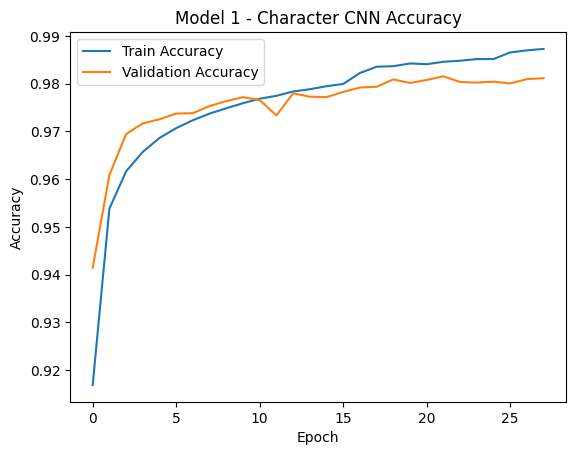

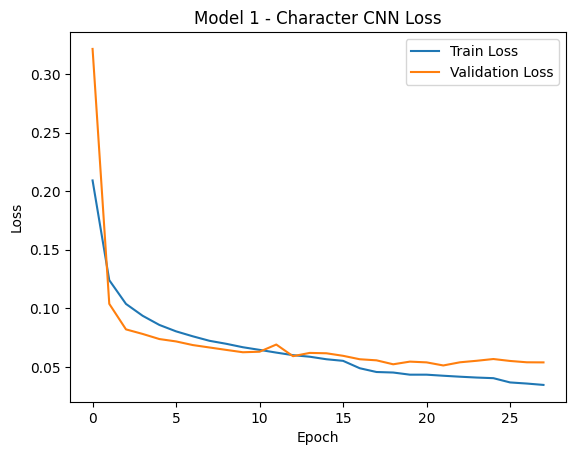

In [11]:
def create_char_cnn_model(vocab_size, max_len):
    model = Sequential([
        Input(shape=(max_len,)),

        Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIM
        ),

        Conv1D(filters=128, kernel_size=5, activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),

        Conv1D(filters=128, kernel_size=3, activation="relu"),
        BatchNormalization(),
        GlobalMaxPooling1D(),

        Dense(128, activation="relu"),
        Dropout(0.30),

        Dense(64, activation="relu"),
        Dropout(0.20),

        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.AUC(name="pr_auc", curve="PR")
        ]
    )

    return model


model_1_cnn = create_char_cnn_model(vocab_size, MAX_LEN)
model_1_cnn.summary()

history_1 = model_1_cnn.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=build_callbacks("model_1_char_cnn"),
    class_weight=class_weight,
    verbose=1
)

plot_history(history_1, "Model 1 - Character CNN")

In [12]:
val_prob_1 = model_1_cnn.predict(X_val_pad, batch_size=2048).ravel()
best_thr_1, best_f1_1 = find_best_threshold(y_val, val_prob_1)

print("Best threshold Model 1:", best_thr_1)
print("Validation F1 Model 1:", best_f1_1)

result_1, test_prob_1 = evaluate_model(
    model_1_cnn,
    X_test_pad,
    y_test,
    "Model 1 - Character CNN",
    threshold=best_thr_1
)

43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step
Best threshold Model 1: 0.43000000000000005
Validation F1 Model 1: 0.9787068221671723
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step

Model 1 - Character CNN
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     50861
           1       0.98      0.97      0.98     36127

    accuracy                           0.98     86988
   macro avg       0.98      0.98      0.98     86988
weighted avg       0.98      0.98      0.98     86988

Confusion Matrix:
[[50260   601]
 [ 1036 35091]]
{'Model': 'Model 1 - Character CNN', 'Threshold': np.float64(0.43000000000000005), 'Accuracy': 0.9811813123649239, 'Precision': 0.9831614927714895, 'Recall': 0.9713233869405155, 'F1-score': 0.9772065887856973, 'ROC-AUC': np.float64(0.9978698731338476), 'PR-AUC': np.float64(0.9973733764484193)}


In [13]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Dense, Dropout, BatchNormalization, Concatenate,
    SpatialDropout1D
)
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

EMBEDDING_DIM = 96
LEARNING_RATE = 1e-3
EPOCHS = 40
BATCH_SIZE = 1024

def create_multikernel_char_cnn(vocab_size, max_len):
    inputs = Input(shape=(max_len,))

    x = Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM
    )(inputs)

    x = SpatialDropout1D(0.15)(x)

    conv3 = Conv1D(filters=128, kernel_size=3, activation="relu", padding="same")(x)
    conv3 = BatchNormalization()(conv3)
    conv3 = GlobalMaxPooling1D()(conv3)

    conv5 = Conv1D(filters=128, kernel_size=5, activation="relu", padding="same")(x)
    conv5 = BatchNormalization()(conv5)
    conv5 = GlobalMaxPooling1D()(conv5)

    conv7 = Conv1D(filters=128, kernel_size=7, activation="relu", padding="same")(x)
    conv7 = BatchNormalization()(conv7)
    conv7 = GlobalMaxPooling1D()(conv7)

    merged = Concatenate()([conv3, conv5, conv7])

    dense = Dense(256, activation="relu")(merged)
    dense = BatchNormalization()(dense)
    dense = Dropout(0.35)(dense)

    dense = Dense(128, activation="relu")(dense)
    dense = BatchNormalization()(dense)
    dense = Dropout(0.25)(dense)

    dense = Dense(64, activation="relu")(dense)
    dense = Dropout(0.15)(dense)

    outputs = Dense(1, activation="sigmoid")(dense)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.AUC(name="pr_auc", curve="PR")
        ]
    )

    return model


model_1_v2 = create_multikernel_char_cnn(vocab_size, MAX_LEN)
model_1_v2.summary()

history_1_v2 = model_1_v2.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=build_callbacks("model_1_v2_multikernel_char_cnn"),
    class_weight=class_weight,
    verbose=1
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 250)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 250, 96)   │     11,520 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 250, 96)   │          0 │ embedding_1[0][0] │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 250, 128)  │     36,992 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 250, 128)  │     61,568 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 250, 128)  │     86,144 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 128)  │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 128)  │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 128)  │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │     98,560 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     32,896 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 339,073 (1.29 MB)

 Trainable params: 337,537 (1.29 MB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 78s 158ms/step - accuracy: 0.9395 - auc: 0.9845 - loss: 0.1570 - pr_auc: 0.9799 - val_accuracy: 0.9492 - val_auc: 0.9894 - val_loss: 0.3081 - val_pr_auc: 0.9867 - learning_rate: 0.0010
Epoch 2/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 48s 121ms/step - accuracy: 0.9653 - auc: 0.9938 - loss: 0.0945 - pr_auc: 0.9918 - val_accuracy: 0.9640 - val_auc: 0.9952 - val_loss: 0.0906 - val_pr_auc: 0.9938 - learning_rate: 0.0010
Epoch 3/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 48s 120ms/step - accuracy: 0.9710 - auc: 0.9955 - loss: 0.0800 - pr_auc: 0.9940 - val_accuracy: 0.9613 - val_auc: 0.9949 - val_loss: 0.1057 - val_pr_auc: 0.9945 - learning_rate: 0.0010
Epoch 4/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 48s 121ms/step - accuracy: 0.9739 - auc: 0.9962 - loss: 0.0718 - pr_auc: 0.9949 - val_accuracy: 0.9756 - val_auc: 0.9965 - val_loss: 0.0669 - val_pr_auc: 0.9956 - learning_rate: 0.0010
Epoch 5/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 48s 121ms/step - accuracy: 0.9761 - auc: 0.9968 - loss: 0.06

In [14]:
val_prob_1_v2 = model_1_v2.predict(X_val_pad, batch_size=2048).ravel()

best_thr_1_v2, best_f1_1_v2 = find_best_threshold(y_val, val_prob_1_v2)

print("Best threshold Model 1 v2:", best_thr_1_v2)
print("Validation F1 Model 1 v2:", best_f1_1_v2)

43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step
Best threshold Model 1 v2: 0.4800000000000001
Validation F1 Model 1 v2: 0.9758326620183894


In [15]:
result_1_v2, test_prob_1_v2 = evaluate_model(
    model_1_v2,
    X_test_pad,
    y_test,
    "Model 1 v2 - Multi-Kernel Character CNN",
    threshold=best_thr_1_v2
)

result_1_v2

43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step

Model 1 v2 - Multi-Kernel Character CNN
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     50861
           1       0.98      0.97      0.98     36127

    accuracy                           0.98     86988
   macro avg       0.98      0.98      0.98     86988
weighted avg       0.98      0.98      0.98     86988

Confusion Matrix:
[[50147   714]
 [ 1000 35127]]
{'Model': 'Model 1 v2 - Multi-Kernel Character CNN', 'Threshold': np.float64(0.4800000000000001), 'Accuracy': 0.9802961327999264, 'Precision': 0.9800786808403783, 'Recall': 0.9723198715642041, 'F1-score': 0.976183859493108, 'ROC-AUC': np.float64(0.9977113479209897), 'PR-AUC': np.float64(0.9972058541842068)}


{'Model': 'Model 1 v2 - Multi-Kernel Character CNN',
 'Threshold': np.float64(0.4800000000000001),
 'Accuracy': 0.9802961327999264,
 'Precision': 0.9800786808403783,
 'Recall': 0.9723198715642041,
 'F1-score': 0.976183859493108,
 'ROC-AUC': np.float64(0.9977113479209897),
 'PR-AUC': np.float64(0.9972058541842068)}

In [16]:
EMBEDDING_DIM = 96
LEARNING_RATE = 1e-3
EPOCHS = 40
BATCH_SIZE = 1024

def create_char_cnn_v3(vocab_size, max_len):
    model = Sequential([
        Input(shape=(max_len,)),

        Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIM
        ),

        Conv1D(filters=160, kernel_size=5, activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.20),

        Conv1D(filters=128, kernel_size=3, activation="relu"),
        BatchNormalization(),
        GlobalMaxPooling1D(),

        Dense(128, activation="relu"),
        Dropout(0.25),

        Dense(64, activation="relu"),
        Dropout(0.15),

        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.AUC(name="pr_auc", curve="PR")
        ]
    )

    return model


model_1_v3 = create_char_cnn_v3(vocab_size, MAX_LEN)
model_1_v3.summary()

history_1_v3 = model_1_v3.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=build_callbacks("model_1_v3_char_cnn"),
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 250, 96)        │        11,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 246, 160)       │        76,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 246, 160)       │           640 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 123, 160)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 123, 160)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 121, 128)       │        61,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 121, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_4          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,033 (687.63 KB)

 Trainable params: 175,457 (685.38 KB)

 Non-trainable params: 576 (2.25 KB)

Epoch 1/40
396/397 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.8701 - auc: 0.9280 - loss: 0.3314 - pr_auc: 0.9042

2026-06-09 21:49:17.862681: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng12{k11=2} for conv %cudnn-conv-bias-activation.7 = (f32[440,128,1,121]{3,2,1,0}, u8[0]{0}) custom-call(f32[440,160,1,123]{3,2,1,0} %bitcast.9705, f32[128,160,1,3]{3,2,1,0} %bitcast.9709, f32[128]{0} %bitcast.12601), window={size=1x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1_1/conv1d_6_1/convolution" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-06-09 21:49:21.584677: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 4.722111034s
Trying algorithm eng12{

397/397 ━━━━━━━━━━━━━━━━━━━━ 61s 127ms/step - accuracy: 0.9210 - auc: 0.9734 - loss: 0.2028 - pr_auc: 0.9658 - val_accuracy: 0.9526 - val_auc: 0.9909 - val_loss: 0.2661 - val_pr_auc: 0.9883 - learning_rate: 0.0010
Epoch 2/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 36s 90ms/step - accuracy: 0.9581 - auc: 0.9911 - loss: 0.1119 - pr_auc: 0.9886 - val_accuracy: 0.9676 - val_auc: 0.9948 - val_loss: 0.0885 - val_pr_auc: 0.9932 - learning_rate: 0.0010
Epoch 3/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 36s 90ms/step - accuracy: 0.9654 - auc: 0.9935 - loss: 0.0939 - pr_auc: 0.9918 - val_accuracy: 0.9713 - val_auc: 0.9957 - val_loss: 0.0772 - val_pr_auc: 0.9944 - learning_rate: 0.0010
Epoch 4/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 36s 90ms/step - accuracy: 0.9695 - auc: 0.9948 - loss: 0.0835 - pr_auc: 0.9933 - val_accuracy: 0.9699 - val_auc: 0.9959 - val_loss: 0.0794 - val_pr_auc: 0.9952 - learning_rate: 0.0010
Epoch 5/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 36s 89ms/step - accuracy: 0.9719 - auc: 0.9955 - loss: 0.0764 - pr_auc: 0.

In [17]:
val_prob_1_v3 = model_1_v3.predict(X_val_pad, batch_size=2048).ravel()

best_thr_1_v3, best_f1_1_v3 = find_best_threshold(y_val, val_prob_1_v3)

print("Best threshold Model 1 v3:", best_thr_1_v3)
print("Validation F1 Model 1 v3:", best_f1_1_v3)

result_1_v3, test_prob_1_v3 = evaluate_model(
    model_1_v3,
    X_test_pad,
    y_test,
    "Model 1 v3 - Optimized Character CNN",
    threshold=best_thr_1_v3
)

result_1_v3

43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step
Best threshold Model 1 v3: 0.32000000000000006
Validation F1 Model 1 v3: 0.9786902792643768
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step

Model 1 v3 - Optimized Character CNN
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     50861
           1       0.98      0.97      0.98     36127

    accuracy                           0.98     86988
   macro avg       0.98      0.98      0.98     86988
weighted avg       0.98      0.98      0.98     86988

Confusion Matrix:
[[50200   661]
 [  947 35180]]
{'Model': 'Model 1 v3 - Optimized Character CNN', 'Threshold': np.float64(0.32000000000000006), 'Accuracy': 0.9815146916816112, 'Precision': 0.9815574342233755, 'Recall': 0.9737869183713013, 'F1-score': 0.9776567363272566, 'ROC-AUC': np.float64(0.9979225492438593), 'PR-AUC': np.float64(0.9974619639468502)}


{'Model': 'Model 1 v3 - Optimized Character CNN',
 'Threshold': np.float64(0.32000000000000006),
 'Accuracy': 0.9815146916816112,
 'Precision': 0.9815574342233755,
 'Recall': 0.9737869183713013,
 'F1-score': 0.9776567363272566,
 'ROC-AUC': np.float64(0.9979225492438593),
 'PR-AUC': np.float64(0.9974619639468502)}

In [18]:
MAX_LEN_V4 = 300

X_train_pad_v4 = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN_V4,
    padding="post",
    truncating="post"
)

X_val_pad_v4 = pad_sequences(
    X_val_seq,
    maxlen=MAX_LEN_V4,
    padding="post",
    truncating="post"
)

X_test_pad_v4 = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN_V4,
    padding="post",
    truncating="post"
)

print("Train:", X_train_pad_v4.shape)
print("Validation:", X_val_pad_v4.shape)
print("Test:", X_test_pad_v4.shape)

Train: (405944, 300)
Validation: (86988, 300)
Test: (86988, 300)


In [19]:
EMBEDDING_DIM = 64
LEARNING_RATE = 1e-3
EPOCHS = 40
BATCH_SIZE = 1024

def create_char_cnn_v4(vocab_size, max_len):
    model = Sequential([
        Input(shape=(max_len,)),

        Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIM
        ),

        Conv1D(filters=128, kernel_size=5, activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),

        Conv1D(filters=128, kernel_size=3, activation="relu"),
        BatchNormalization(),
        GlobalMaxPooling1D(),

        Dense(128, activation="relu"),
        Dropout(0.30),

        Dense(64, activation="relu"),
        Dropout(0.20),

        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.AUC(name="pr_auc", curve="PR")
        ]
    )

    return model


model_1_v4 = create_char_cnn_v4(vocab_size, MAX_LEN_V4)
model_1_v4.summary()

history_1_v4 = model_1_v4.fit(
    X_train_pad_v4,
    y_train,
    validation_data=(X_val_pad_v4, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=build_callbacks("model_1_v4_char_cnn_maxlen300"),
    class_weight=class_weight,
    verbose=1
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 300, 64)        │         7,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 296, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 296, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 148, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 148, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 146, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 146, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_5          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,905 (484.00 KB)

 Trainable params: 123,393 (482.00 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 54s 112ms/step - accuracy: 0.9071 - auc: 0.9660 - loss: 0.2383 - pr_auc: 0.9544 - val_accuracy: 0.9442 - val_auc: 0.9898 - val_loss: 0.2989 - val_pr_auc: 0.9870 - learning_rate: 0.0010
Epoch 2/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 35s 88ms/step - accuracy: 0.9512 - auc: 0.9889 - loss: 0.1308 - pr_auc: 0.9853 - val_accuracy: 0.9623 - val_auc: 0.9933 - val_loss: 0.0991 - val_pr_auc: 0.9915 - learning_rate: 0.0010
Epoch 3/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 35s 88ms/step - accuracy: 0.9598 - auc: 0.9921 - loss: 0.1086 - pr_auc: 0.9896 - val_accuracy: 0.9653 - val_auc: 0.9948 - val_loss: 0.0904 - val_pr_auc: 0.9935 - learning_rate: 0.0010
Epoch 4/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - accuracy: 0.9648 - auc: 0.9938 - loss: 0.0955 - pr_auc: 0.9918 - val_accuracy: 0.9692 - val_auc: 0.9957 - val_loss: 0.0807 - val_pr_auc: 0.9945 - learning_rate: 0.0010
Epoch 5/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 35s 88ms/step - accuracy: 0.9677 - auc: 0.9946 - loss: 0.0879 -

In [20]:
val_prob_1_v4 = model_1_v4.predict(X_val_pad_v4, batch_size=2048).ravel()

best_thr_1_v4, best_f1_1_v4 = find_best_threshold(y_val, val_prob_1_v4)

print("Best threshold Model 1 v4:", best_thr_1_v4)
print("Validation F1 Model 1 v4:", best_f1_1_v4)

result_1_v4, test_prob_1_v4 = evaluate_model(
    model_1_v4,
    X_test_pad_v4,
    y_test,
    "Model 1 v4 - Character CNN MAX_LEN 300",
    threshold=best_thr_1_v4
)

result_1_v4

43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step
Best threshold Model 1 v4: 0.31000000000000005
Validation F1 Model 1 v4: 0.9785113412365696
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step

Model 1 v4 - Character CNN MAX_LEN 300
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     50861
           1       0.98      0.98      0.98     36127

    accuracy                           0.98     86988
   macro avg       0.98      0.98      0.98     86988
weighted avg       0.98      0.98      0.98     86988

Confusion Matrix:
[[50122   739]
 [  899 35228]]
{'Model': 'Model 1 v4 - Character CNN MAX_LEN 300', 'Threshold': np.float64(0.31000000000000005), 'Accuracy': 0.9811698165264174, 'Precision': 0.979453387827731, 'Recall': 0.9751155645362195, 'F1-score': 0.9772796626626349, 'ROC-AUC': np.float64(0.9979523203074605), 'PR-AUC': np.float64(0.9974959514721721)}


{'Model': 'Model 1 v4 - Character CNN MAX_LEN 300',
 'Threshold': np.float64(0.31000000000000005),
 'Accuracy': 0.9811698165264174,
 'Precision': 0.979453387827731,
 'Recall': 0.9751155645362195,
 'F1-score': 0.9772796626626349,
 'ROC-AUC': np.float64(0.9979523203074605),
 'PR-AUC': np.float64(0.9974959514721721)}

In [21]:
MAX_LEN = 250

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print(X_train_pad.shape)
print(X_val_pad.shape)
print(X_test_pad.shape)

(405944, 250)
(86988, 250)
(86988, 250)


In [22]:
EMBEDDING_DIM = 64
LEARNING_RATE = 1e-3
EPOCHS = 40
BATCH_SIZE = 1024

def create_char_cnn_v5(vocab_size, max_len):
    model = Sequential([
        Input(shape=(max_len,)),

        Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIM
        ),

        Conv1D(filters=128, kernel_size=5, activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),

        Conv1D(filters=128, kernel_size=3, activation="relu"),
        BatchNormalization(),
        GlobalMaxPooling1D(),

        Dense(128, activation="relu"),
        Dropout(0.30),

        Dense(64, activation="relu"),
        Dropout(0.20),

        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.AUC(name="pr_auc", curve="PR")
        ]
    )

    return model


model_1_v5 = create_char_cnn_v5(vocab_size, MAX_LEN)
model_1_v5.summary()

history_1_v5 = model_1_v5.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=build_callbacks("model_1_v5_char_cnn_no_class_weight"),
    verbose=1
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 250, 64)        │         7,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 246, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 246, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 123, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 123, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 121, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 121, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_6          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,905 (484.00 KB)

 Trainable params: 123,393 (482.00 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 35s 73ms/step - accuracy: 0.9093 - auc: 0.9677 - loss: 0.2263 - pr_auc: 0.9580 - val_accuracy: 0.9459 - val_auc: 0.9908 - val_loss: 0.3455 - val_pr_auc: 0.9884 - learning_rate: 0.0010
Epoch 2/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.9535 - auc: 0.9895 - loss: 0.1230 - pr_auc: 0.9865 - val_accuracy: 0.9621 - val_auc: 0.9937 - val_loss: 0.1011 - val_pr_auc: 0.9921 - learning_rate: 0.0010
Epoch 3/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.9613 - auc: 0.9923 - loss: 0.1036 - pr_auc: 0.9901 - val_accuracy: 0.9646 - val_auc: 0.9944 - val_loss: 0.0928 - val_pr_auc: 0.9931 - learning_rate: 0.0010
Epoch 4/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step - accuracy: 0.9658 - auc: 0.9937 - loss: 0.0925 - pr_auc: 0.9919 - val_accuracy: 0.9711 - val_auc: 0.9956 - val_loss: 0.0782 - val_pr_auc: 0.9944 - learning_rate: 0.0010
Epoch 5/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.9689 - auc: 0.9946 - loss: 0.0848 - 

In [23]:
val_prob_1_v5 = model_1_v5.predict(X_val_pad, batch_size=2048).ravel()

best_thr_1_v5, best_f1_1_v5 = find_best_threshold(y_val, val_prob_1_v5)

print("Best threshold Model 1 v5:", best_thr_1_v5)
print("Validation F1 Model 1 v5:", best_f1_1_v5)

result_1_v5, test_prob_1_v5 = evaluate_model(
    model_1_v5,
    X_test_pad,
    y_test,
    "Model 1 v5 - Character CNN No Class Weight",
    threshold=best_thr_1_v5
)

result_1_v5

43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step
Best threshold Model 1 v5: 0.4100000000000001
Validation F1 Model 1 v5: 0.9773031079425197
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step

Model 1 v5 - Character CNN No Class Weight
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     50861
           1       0.98      0.97      0.98     36127

    accuracy                           0.98     86988
   macro avg       0.98      0.98      0.98     86988
weighted avg       0.98      0.98      0.98     86988

Confusion Matrix:
[[50253   608]
 [ 1088 35039]]
{'Model': 'Model 1 v5 - Character CNN No Class Weight', 'Threshold': np.float64(0.4100000000000001), 'Accuracy': 0.9805030578930427, 'Precision': 0.9829438662440037, 'Recall': 0.969884020261854, 'F1-score': 0.9763702733580405, 'ROC-AUC': np.float64(0.9977342692943273), 'PR-AUC': np.float64(0.9972042272909508)}


{'Model': 'Model 1 v5 - Character CNN No Class Weight',
 'Threshold': np.float64(0.4100000000000001),
 'Accuracy': 0.9805030578930427,
 'Precision': 0.9829438662440037,
 'Recall': 0.969884020261854,
 'F1-score': 0.9763702733580405,
 'ROC-AUC': np.float64(0.9977342692943273),
 'PR-AUC': np.float64(0.9972042272909508)}

In [24]:
import random
import numpy as np
import tensorflow as tf

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def create_char_cnn_v1_for_ensemble(vocab_size, max_len):
    model = Sequential([
        Input(shape=(max_len,)),

        Embedding(
            input_dim=vocab_size,
            output_dim=64
        ),

        Conv1D(filters=128, kernel_size=5, activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),

        Conv1D(filters=128, kernel_size=3, activation="relu"),
        BatchNormalization(),
        GlobalMaxPooling1D(),

        Dense(128, activation="relu"),
        Dropout(0.30),

        Dense(64, activation="relu"),
        Dropout(0.20),

        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.AUC(name="pr_auc", curve="PR")
        ]
    )

    return model

In [25]:
seeds = [42, 2024, 3407]

ensemble_val_probs = []
ensemble_test_probs = []
ensemble_results = []

for seed in seeds:
    print(f"\n==============================")
    print(f"Training CNN seed: {seed}")
    print(f"==============================")

    set_seed(seed)

    model_seed = create_char_cnn_v1_for_ensemble(vocab_size, MAX_LEN)

    history_seed = model_seed.fit(
        X_train_pad,
        y_train,
        validation_data=(X_val_pad, y_val),
        epochs=40,
        batch_size=1024,
        callbacks=build_callbacks(f"model_1_v6_seed_{seed}"),
        class_weight=class_weight,
        verbose=1
    )

    val_prob_seed = model_seed.predict(X_val_pad, batch_size=2048).ravel()
    test_prob_seed = model_seed.predict(X_test_pad, batch_size=2048).ravel()

    best_thr_seed, best_f1_seed = find_best_threshold(y_val, val_prob_seed)

    print("Seed:", seed)
    print("Best threshold:", best_thr_seed)
    print("Validation F1:", best_f1_seed)

    result_seed, _ = evaluate_model(
        model_seed,
        X_test_pad,
        y_test,
        f"Model 1 v6 - CNN Seed {seed}",
        threshold=best_thr_seed
    )

    ensemble_val_probs.append(val_prob_seed)
    ensemble_test_probs.append(test_prob_seed)
    ensemble_results.append(result_seed)


Training CNN seed: 42
Epoch 1/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 36s 73ms/step - accuracy: 0.8983 - auc: 0.9594 - loss: 0.2659 - pr_auc: 0.9452 - val_accuracy: 0.9442 - val_auc: 0.9873 - val_loss: 0.4014 - val_pr_auc: 0.9838 - learning_rate: 0.0010
Epoch 2/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.9501 - auc: 0.9883 - loss: 0.1341 - pr_auc: 0.9844 - val_accuracy: 0.9618 - val_auc: 0.9932 - val_loss: 0.1061 - val_pr_auc: 0.9912 - learning_rate: 0.0010
Epoch 3/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.9590 - auc: 0.9917 - loss: 0.1115 - pr_auc: 0.9890 - val_accuracy: 0.9653 - val_auc: 0.9946 - val_loss: 0.0927 - val_pr_auc: 0.9932 - learning_rate: 0.0010
Epoch 4/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step - accuracy: 0.9636 - auc: 0.9933 - loss: 0.0990 - pr_auc: 0.9913 - val_accuracy: 0.9702 - val_auc: 0.9954 - val_loss: 0.0804 - val_pr_auc: 0.9939 - learning_rate: 0.0010
Epoch 5/40
397/397 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.9670 - auc: 0

In [26]:
ensemble_val_prob = np.mean(ensemble_val_probs, axis=0)
ensemble_test_prob = np.mean(ensemble_test_probs, axis=0)

best_thr_ensemble, best_f1_ensemble = find_best_threshold(y_val, ensemble_val_prob)

ensemble_pred = (ensemble_test_prob >= best_thr_ensemble).astype(int)

cnn_ensemble_result = {
    "Model": "Model 1 v6 - Character CNN Seed Ensemble",
    "Threshold": best_thr_ensemble,
    "Accuracy": accuracy_score(y_test, ensemble_pred),
    "Precision": precision_score(y_test, ensemble_pred, zero_division=0),
    "Recall": recall_score(y_test, ensemble_pred, zero_division=0),
    "F1-score": f1_score(y_test, ensemble_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, ensemble_test_prob),
    "PR-AUC": average_precision_score(y_test, ensemble_test_prob)
}

print(cnn_ensemble_result)
print(classification_report(y_test, ensemble_pred, zero_division=0))
print(confusion_matrix(y_test, ensemble_pred))

{'Model': 'Model 1 v6 - Character CNN Seed Ensemble', 'Threshold': np.float64(0.4100000000000001), 'Accuracy': 0.9834689842277096, 'Precision': 0.9841181232031708, 'Recall': 0.9759459683892934, 'F1-score': 0.98001500958946, 'ROC-AUC': np.float64(0.9984079003580815), 'PR-AUC': np.float64(0.9980193595587254)}
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     50861
           1       0.98      0.98      0.98     36127

    accuracy                           0.98     86988
   macro avg       0.98      0.98      0.98     86988
weighted avg       0.98      0.98      0.98     86988

[[50292   569]
 [  869 35258]]


In [27]:
import os
import json
import pickle
import numpy as np
import pandas as pd

SAVE_DIR = "/kaggle/working/model_1_character_cnn_final"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Save directory:", SAVE_DIR)

Save directory: /kaggle/working/model_1_character_cnn_final


In [28]:
with open(f"{SAVE_DIR}/url_char_tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved.")

Tokenizer saved.


In [29]:
model1_final_results = pd.DataFrame([
    {
        "Model": "Model 1 v1 - Character CNN",
        "Threshold": 0.4100000000000001,
        "Accuracy": 0.9813997332965466,
        "Precision": 0.9827919079996642,
        "Recall": 0.9722368311788967,
        "F1-score": 0.9774858764923607,
        "ROC-AUC": 0.9979802828917399,
        "PR-AUC": 0.9975002803443733,
        "TN": 50246,
        "FP": 615,
        "FN": 1003,
        "TP": 35124
    },
    {
        "Model": "Model 1 v2 - Multi-Kernel Character CNN",
        "Threshold": 0.49000000000000005,
        "Accuracy": 0.9793419782038902,
        "Precision": 0.9805700207178454,
        "Recall": 0.9694688183353171,
        "F1-score": 0.9749878210035493,
        "ROC-AUC": 0.9975260487241652,
        "PR-AUC": 0.9969718027276925,
        "TN": 50167,
        "FP": 694,
        "FN": 1103,
        "TP": 35024
    },
    {
        "Model": "Model 1 v3 - Optimized Character CNN",
        "Threshold": 0.33,
        "Accuracy": 0.9801466868993425,
        "Precision": 0.9787352482743265,
        "Recall": 0.9733440363163285,
        "F1-score": 0.9760321976268128,
        "ROC-AUC": 0.9977765851525751,
        "PR-AUC": 0.9972491714827472,
        "TN": 50097,
        "FP": 764,
        "FN": 963,
        "TP": 35164
    },
    {
        "Model": "Model 1 v4 - Character CNN MAX_LEN 300",
        "Threshold": 0.4100000000000001,
        "Accuracy": 0.9793879615579161,
        "Precision": 0.9798200011180055,
        "Recall": 0.9703545824452625,
        "F1-score": 0.9750643209790696,
        "ROC-AUC": 0.9976319046298978,
        "PR-AUC": 0.9970617392082624,
        "TN": 50139,
        "FP": 722,
        "FN": 1071,
        "TP": 35056
    },
    {
        "Model": "Model 1 v5 - Character CNN No Class Weight",
        "Threshold": 0.36000000000000004,
        "Accuracy": 0.980686991309146,
        "Precision": 0.9827620035316871,
        "Recall": 0.9705206632158773,
        "F1-score": 0.9766029747646371,
        "ROC-AUC": 0.9978974601987974,
        "PR-AUC": 0.9974152175694783,
        "TN": 50246,
        "FP": 615,
        "FN": 1065,
        "TP": 35062
    },
    {
        "Model": "Model 1 v6 - Character CNN Seed Ensemble",
        "Threshold": 0.4100000000000001,
        "Accuracy": 0.9837678760288775,
        "Precision": 0.9861636277063552,
        "Recall": 0.9745896420959393,
        "F1-score": 0.9803424752888765,
        "ROC-AUC": 0.9984950774425538,
        "PR-AUC": 0.9981095389818174,
        "TN": 50367,
        "FP": 494,
        "FN": 918,
        "TP": 35209
    }
])

model1_final_results.to_csv(
    f"{SAVE_DIR}/model1_character_cnn_all_results.csv",
    index=False
)

display(model1_final_results)
print("Model 1 results saved.")

,Model,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Model 1 v1 - Character CNN,0.41,0.981400,0.982792,0.972237,0.977486,0.997980,0.997500,50246,615,1003,35124
1,Model 1 v2 - Multi-Kernel Character CNN,0.49,0.979342,0.980570,0.969469,0.974988,0.997526,0.996972,50167,694,1103,35024
2,Model 1 v3 - Optimized Character CNN,0.33,0.980147,0.978735,0.973344,0.976032,0.997777,0.997249,50097,764,963,35164
3,Model 1 v4 - Character CNN MAX_LEN 300,0.41,0.979388,0.979820,0.970355,0.975064,0.997632,0.997062,50139,722,1071,35056
4,Model 1 v5 - Character CNN No Class Weight,0.36,0.980687,0.982762,0.970521,0.976603,0.997897,0.997415,50246,615,1065,35062
5,Model 1 v6 - Character CNN Seed Ensemble,0.41,0.983768,0.986164,0.974590,0.980342,0.998495,0.998110,50367,494,918,35209


Model 1 results saved.


In [30]:
model1_hyperparameters = {
    "final_model": "Model 1 v6 - Character CNN Seed Ensemble",
    "input_type": "Raw URL only",
    "features_used": False,
    "used_columns": ["url", "label"],
    "max_len": 250,
    "tokenization": "character-level",
    "padding": "post",
    "truncating": "post",
    "embedding_dim": 64,
    "vocab_size": int(vocab_size),
    "cnn_architecture": {
        "embedding": {
            "input_dim": int(vocab_size),
            "output_dim": 64
        },
        "conv1": {
            "filters": 128,
            "kernel_size": 5,
            "activation": "relu"
        },
        "pooling": "MaxPooling1D(pool_size=2)",
        "dropout_after_conv1": 0.25,
        "conv2": {
            "filters": 128,
            "kernel_size": 3,
            "activation": "relu"
        },
        "global_pooling": "GlobalMaxPooling1D",
        "dense1": {
            "units": 128,
            "activation": "relu",
            "dropout": 0.30
        },
        "dense2": {
            "units": 64,
            "activation": "relu",
            "dropout": 0.20
        },
        "output": {
            "units": 1,
            "activation": "sigmoid"
        }
    },
    "training": {
        "epochs": 40,
        "batch_size": 1024,
        "optimizer": "Adam",
        "learning_rate": 0.001,
        "loss": "binary_crossentropy",
        "class_weight": "balanced",
        "early_stopping_monitor": "val_loss",
        "early_stopping_patience": 6,
        "reduce_lr_monitor": "val_loss",
        "reduce_lr_factor": 0.5,
        "reduce_lr_patience": 3
    },
    "ensemble": {
        "enabled": True,
        "method": "average predicted probabilities",
        "seeds": [42, 2024, 3407],
        "final_threshold": 0.4100000000000001
    },
    "final_test_metrics": {
        "accuracy": 0.9837678760288775,
        "precision": 0.9861636277063552,
        "recall": 0.9745896420959393,
        "f1_score": 0.9803424752888765,
        "roc_auc": 0.9984950774425538,
        "pr_auc": 0.9981095389818174,
        "confusion_matrix": {
            "tn": 50367,
            "fp": 494,
            "fn": 918,
            "tp": 35209
        }
    }
}

with open(f"{SAVE_DIR}/model1_character_cnn_hyperparameters.json", "w", encoding="utf-8") as f:
    json.dump(model1_hyperparameters, f, indent=4, ensure_ascii=False)

print("Hyperparameters saved.")

Hyperparameters saved.


In [31]:
ensemble_val_prob
ensemble_test_prob
ensemble_pred

array([0, 0, 1, ..., 0, 0, 0], shape=(86988,))

In [32]:
np.save(f"{SAVE_DIR}/model1_ensemble_val_prob.npy", ensemble_val_prob)
np.save(f"{SAVE_DIR}/model1_ensemble_test_prob.npy", ensemble_test_prob)
np.save(f"{SAVE_DIR}/model1_ensemble_test_pred.npy", ensemble_pred)

print("Ensemble probabilities and predictions saved.")

Ensemble probabilities and predictions saved.


In [33]:
np.save(f"{SAVE_DIR}/y_test.npy", y_test)
np.save(f"{SAVE_DIR}/y_val.npy", y_val)

print("Validation and test labels saved.")

Validation and test labels saved.


In [34]:
split_info = {
    "dataset_path": "/kaggle/input/datasets/elifzelik/phishing-url-features-dataset/final_dataset.csv",
    "total_samples_used": int(len(df)),
    "train_samples": int(len(X_train_url)),
    "validation_samples": int(len(X_val_url)),
    "test_samples": int(len(X_test_url)),
    "split_ratio": {
        "train": 0.70,
        "validation": 0.15,
        "test": 0.15
    },
    "random_state": 42,
    "stratified": True,
    "label_distribution_full": {
        str(k): int(v) for k, v in pd.Series(labels).value_counts().to_dict().items()
    },
    "label_distribution_train": {
        str(k): int(v) for k, v in pd.Series(y_train).value_counts().to_dict().items()
    },
    "label_distribution_validation": {
        str(k): int(v) for k, v in pd.Series(y_val).value_counts().to_dict().items()
    },
    "label_distribution_test": {
        str(k): int(v) for k, v in pd.Series(y_test).value_counts().to_dict().items()
    }
}

with open(f"{SAVE_DIR}/data_split_info.json", "w", encoding="utf-8") as f:
    json.dump(split_info, f, indent=4, ensure_ascii=False)

print("Split info saved.")

Split info saved.


In [35]:
import os

for file in os.listdir("/kaggle/working"):
    if "model_1_v6_seed" in file and file.endswith(".keras"):
        print(file)

model_1_v6_seed_3407.keras
model_1_v6_seed_2024.keras
model_1_v6_seed_42.keras


In [36]:
import shutil

seed_model_files = [
    "model_1_v6_seed_42.keras",
    "model_1_v6_seed_2024.keras",
    "model_1_v6_seed_3407.keras"
]

for file in seed_model_files:
    src = f"/kaggle/working/{file}"
    dst = f"{SAVE_DIR}/{file}"

    if os.path.exists(src):
        shutil.copy(src, dst)
        print("Copied:", file)
    else:
        print("Missing:", file)

Copied: model_1_v6_seed_42.keras
Copied: model_1_v6_seed_2024.keras
Copied: model_1_v6_seed_3407.keras


In [37]:
model1_report_text = """
Model 1 was designed as a raw URL-based character-level Convolutional Neural Network (Character CNN). 
Only the URL string and its corresponding binary label were used; no handcrafted features were provided to the model. 
URLs were tokenized at the character level and padded/truncated to a maximum length of 250 characters.

The initial Character CNN architecture consisted of an embedding layer, two Conv1D layers, batch normalization, max/global pooling, dropout regularization, and fully connected layers. 
Several variations were tested, including a multi-kernel CNN, a larger optimized CNN, an increased maximum URL length of 300, and a no-class-weight setting. 
Among single-model variants, the original Character CNN configuration achieved the best general performance.

To improve robustness, the final Model 1 used a seed ensemble strategy. 
The same Character CNN architecture was trained using three different random seeds: 42, 2024, and 3407. 
Final predictions were obtained by averaging the predicted probabilities of the three CNN models. 
The classification threshold was tuned on the validation set and set to 0.41 for the final test evaluation.

The final Character CNN seed ensemble achieved an accuracy of 0.9838, precision of 0.9862, recall of 0.9746, F1-score of 0.9803, ROC-AUC of 0.9985, and PR-AUC of 0.9981 on the held-out test set. 
The final confusion matrix was TN=50367, FP=494, FN=918, and TP=35209.
"""

with open(f"{SAVE_DIR}/model1_character_cnn_report_summary.txt", "w", encoding="utf-8") as f:
    f.write(model1_report_text)

print("Report summary saved.")

Report summary saved.


In [38]:
import shutil

zip_path = "/kaggle/working/model_1_character_cnn_final.zip"

shutil.make_archive(
    base_name=zip_path.replace(".zip", ""),
    format="zip",
    root_dir=SAVE_DIR
)

print("ZIP created:", zip_path)

ZIP created: /kaggle/working/model_1_character_cnn_final.zip


In [39]:
print("Files in final save directory:")
for file in os.listdir(SAVE_DIR):
    print(file)

Files in final save directory:
model_1_v6_seed_3407.keras
url_char_tokenizer.pkl
data_split_info.json
model1_character_cnn_all_results.csv
model1_ensemble_test_pred.npy
y_val.npy
model_1_v6_seed_2024.keras
model1_ensemble_val_prob.npy
model_1_v6_seed_42.keras
model1_character_cnn_report_summary.txt
y_test.npy
model1_character_cnn_hyperparameters.json
model1_ensemble_test_prob.npy
